## Performance plots for generating an upper triangular matrix

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [2]:
def add_stats(df):
    # Input number of bytes per element
    df["out_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * df["size"] * df["out_bytes_per_elem"]
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [3]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"

In [4]:
df_baseline = pd.read_csv(f"../../bench_results_gen_lower_{dtype}.csv")
add_stats(df_baseline)
df_baseline["S"] = "gen_lower"

df = pd.concat([df_baseline])

## Paper plots

/tmp/ipykernel_3343710/877633760.py:1: UserWarning: The markers list has more values (4) than needed (1), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='time_us', **_SNS_PARAMS)


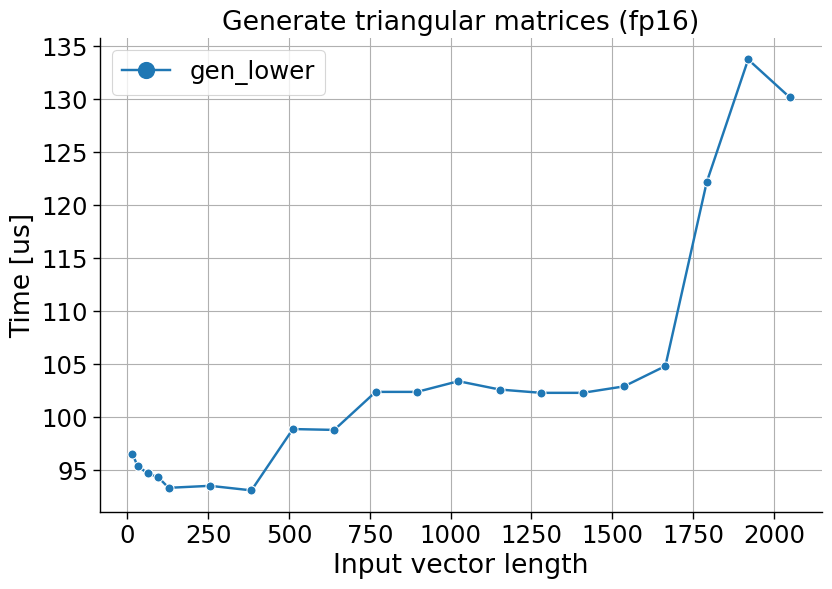

<Figure size 870x627 with 0 Axes>

In [5]:
ax = sns.lineplot(data=df, x='size', y='time_us', **_SNS_PARAMS)

ax.set_title(f"Generate triangular matrices ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Time [us]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"gen_lower_time_us_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_3343710/3435470329.py:1: UserWarning: The markers list has more values (4) than needed (1), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)


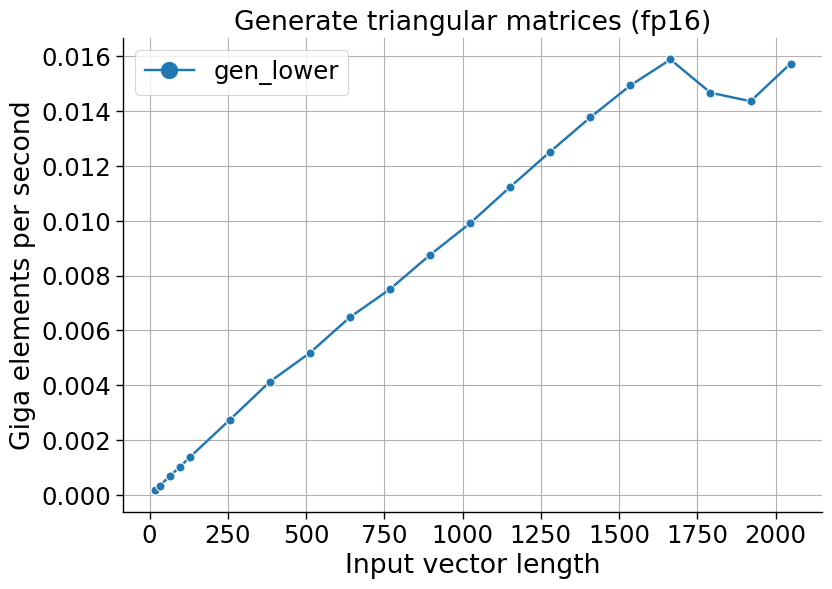

<Figure size 870x627 with 0 Axes>

In [6]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"Generate triangular matrices ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"gen_lower_gelemps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_3343710/3969072843.py:1: UserWarning: The markers list has more values (4) than needed (1), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)


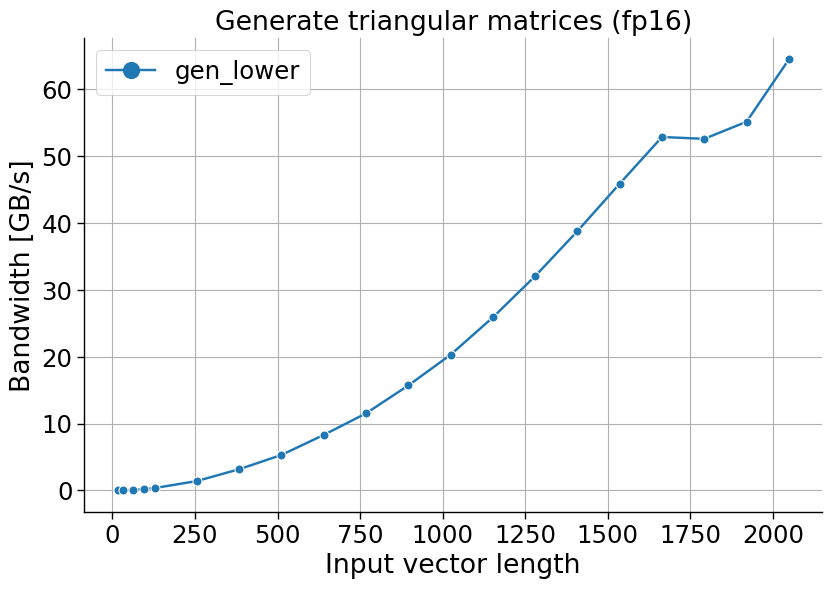

<Figure size 870x627 with 0 Axes>

In [7]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"Generate triangular matrices ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"gen_lower_bw_gbps_{dtype}.png")
plt.show()
plt.clf()


In [8]:
df

,operator,dtype,size,density,outputsize,time_us,out_bytes_per_elem,mem_bytes,gelemps,bw_gbps,S
0,gen_lower,fp16,16,None,256,96.48,2,512,0.000166,0.005307,gen_lower
1,gen_lower,fp16,32,None,1024,95.33,2,2048,0.000336,0.021483,gen_lower
2,gen_lower,fp16,64,None,4096,94.64,2,8192,0.000676,0.086560,gen_lower
3,gen_lower,fp16,96,None,9216,94.27,2,18432,0.001018,0.195523,gen_lower
4,gen_lower,fp16,128,None,16384,93.28,2,32768,0.001372,0.351286,gen_lower
5,gen_lower,fp16,256,None,65536,93.47,2,131072,0.002739,1.402290,gen_lower
6,gen_lower,fp16,384,None,147456,93.04,2,294912,0.004127,3.169733,gen_lower
7,gen_lower,fp16,512,None,262144,98.83,2,524288,0.005181,5.304948,gen_lower
8,gen_lower,fp16,640,None,409600,98.75,2,819200,0.006481,8.295696,gen_lower
9,gen_lower,fp16,768,None,589824,102.34,2,1179648,0.007504,11.526754,gen_lower
